# Ride Booking Exploratory Analysis

## Task 2: Exploratory Analysis and Visual Summary

This notebook analyzes the cleaned ride booking dataset from Task 1.

The analysis focuses on:
- Trip volume
- Revenue
- Peak booking hours
- City-wise usage
- Driver ratings

The purpose is to identify useful business insights for RapidRide's non-technical staff.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
os.makedirs("../outputs/charts", exist_ok=True)

print("Chart folder is ready!")

Chart folder is ready!


In [5]:
def load_cleaned_data():
    """
    Load the cleaned ride booking dataset from Task 1.
    """

    file_path = "../data/cleaned/cleaned_bookings.csv"

    df = pd.read_csv(file_path)

    # Convert Date column back to datetime for time-based analysis
    df["Date"] = pd.to_datetime(df["Date"])

    return df

In [6]:
df = load_cleaned_data()

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 103024
Columns: 18


In [7]:
df.head()

,Date,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating
0,2024-07-26 14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,Not Applicable,Personal & Car related issue,Not Applicable,Not Applicable,444,Not Applicable,0,NaN,NaN
1,2024-07-25 22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,Not Applicable,Not Applicable,No,Not Applicable,158,Cash,13,4.1,4.0
2,2024-07-30 19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,Not Applicable,Not Applicable,No,Not Applicable,386,UPI,40,4.2,4.8
3,2024-07-22 03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,Driver is not moving towards pickup location,Not Applicable,Not Applicable,Not Applicable,384,Not Applicable,0,NaN,NaN
4,2024-07-02 09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,Not Applicable,Not Applicable,No,Not Applicable,822,Credit Card,45,4.0,3.0


In [8]:
print("Columns in the dataset:")
print(df.columns.tolist())

Columns in the dataset:
['Date', 'Booking_ID', 'Booking_Status', 'Customer_ID', 'Vehicle_Type', 'Pickup_Location', 'Drop_Location', 'V_TAT', 'C_TAT', 'Canceled_Rides_by_Customer', 'Canceled_Rides_by_Driver', 'Incomplete_Rides', 'Incomplete_Rides_Reason', 'Booking_Value', 'Payment_Method', 'Ride_Distance', 'Driver_Ratings', 'Customer_Rating']


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103024 entries, 0 to 103023
Data columns (total 18 columns):
 #   Column                      Non-Null Count   Dtype         
---  ------                      --------------   -----         
 0   Date                        103024 non-null  datetime64[ns]
 1   Booking_ID                  103024 non-null  object        
 2   Booking_Status              103024 non-null  object        
 3   Customer_ID                 103024 non-null  object        
 4   Vehicle_Type                103024 non-null  object        
 5   Pickup_Location             103024 non-null  object        
 6   Drop_Location               103024 non-null  object        
 7   V_TAT                       63967 non-null   float64       
 8   C_TAT                       63967 non-null   float64       
 9   Canceled_Rides_by_Customer  103024 non-null  object        
 10  Canceled_Rides_by_Driver    103024 non-null  object        
 11  Incomplete_Rides            103024 non-

In [10]:
booking_status = df["Booking_Status"].value_counts()

print(booking_status)

Booking_Status
Success                 63967
Canceled by Driver      18434
Canceled by Customer    10499
Driver Not Found        10124
Name: count, dtype: int64


In [11]:
successful_rides = df[df["Booking_Status"] == "Success"].copy()

print("Successful rides:", len(successful_rides))

Successful rides: 63967


In [12]:
df["Hour"] = df["Date"].dt.hour

print(df[["Date", "Hour"]].head())

                 Date  Hour
0 2024-07-26 14:00:00    14
1 2024-07-25 22:20:00    22
2 2024-07-30 19:59:00    19
3 2024-07-22 03:15:00     3
4 2024-07-02 09:02:00     9


In [13]:
trips_by_hour = df.groupby("Hour").size()

print(trips_by_hour)

Hour
0     4318
1     4329
2     4305
3     4201
4     4263
5     4264
6     4271
7     4304
8     4374
9     4347
10    4334
11    4272
12    4408
13    4285
14    4232
15    4376
16    4261
17    4353
18    4176
19    4271
20    4228
21    4343
22    4283
23    4226
dtype: int64


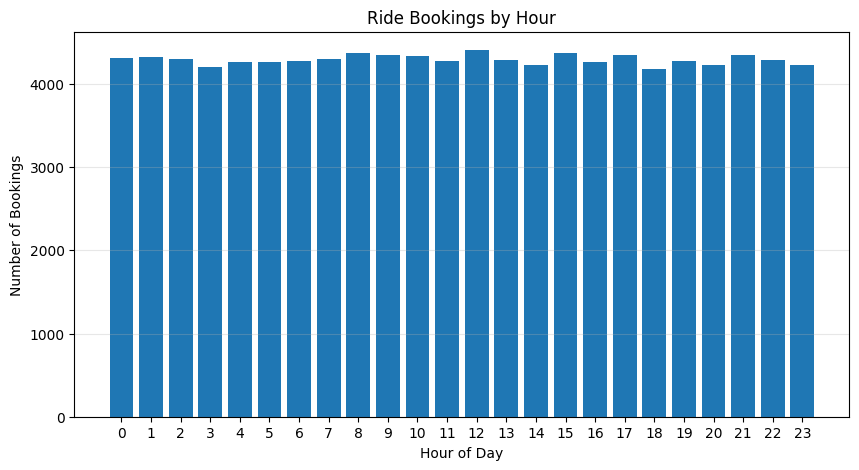

In [14]:
plt.figure(figsize=(10, 5))

plt.bar(trips_by_hour.index, trips_by_hour.values)

plt.title("Ride Bookings by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Bookings")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../outputs/charts/trips_by_hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight — Peak Booking Hours

The hourly booking analysis shows how ride demand changes throughout the day. 
The busiest hours represent periods of higher customer demand, while lower-volume 
hours indicate periods of relatively lower demand. RapidRide can use this 
information to plan driver availability and allocate vehicles according to 
customer demand.

In [15]:
trips_over_time = df.groupby(df["Date"].dt.date).size()

print(trips_over_time.head())

Date
2024-07-01    3351
2024-07-02    3388
2024-07-03    3358
2024-07-04    3274
2024-07-05    3306
dtype: int64


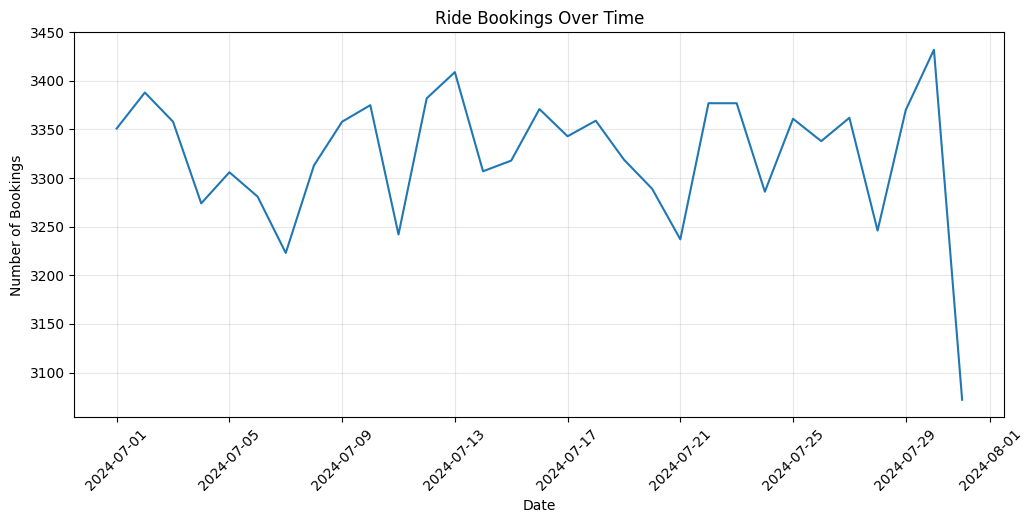

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    trips_over_time.index,
    trips_over_time.values
)

plt.title("Ride Bookings Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.savefig(
    "../outputs/charts/trips_over_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight — Booking Volume Over Time

The time-series analysis shows how the number of ride bookings changes across the 
available dates in the dataset. Periods with higher booking volume indicate 
stronger demand, while lower-volume periods indicate relatively lower demand. 
RapidRide can use these demand patterns to support driver scheduling and vehicle 
availability planning.

In [17]:
total_booking_value = df["Booking_Value"].sum()

print("Total booking value:", total_booking_value)

Total booking value: 56534614


In [18]:
successful_revenue = successful_rides["Booking_Value"].sum()

print("Booking value from successful rides:", successful_revenue)

Booking value from successful rides: 35080467


In [19]:
df["Booking_Value"].sum()

np.int64(56534614)

In [20]:
revenue_by_city = (
    successful_rides
    .groupby("Pickup_Location")["Booking_Value"]
    .sum()
    .sort_values(ascending=False)
)

print(revenue_by_city)

Pickup_Location
RT Nagar                777106
Nagarbhavi              773073
Banashankari            771628
Yeshwanthpur            748319
Frazer Town             738003
Magadi Road             734480
Ramamurthy Nagar        731591
MG Road                 729119
Basavanagudi            728652
BTM Layout              721656
HSR Layout              720015
Richmond Town           718608
KR Puram                717529
Cox Town                715618
Kammanahalli            712157
Varthur                 712121
JP Nagar                710496
Koramangala             708896
Sahakar Nagar           708264
Jayanagar               708237
Tumkur Road             704608
Malleshwaram            703439
Whitefield              701707
Indiranagar             701372
Shivajinagar            700700
Mysore Road             700650
Hennur                  700622
Kengeri                 698052
Rajarajeshwari Nagar    697971
Peenya                  697805
Shantinagar             695703
Hulimavu               

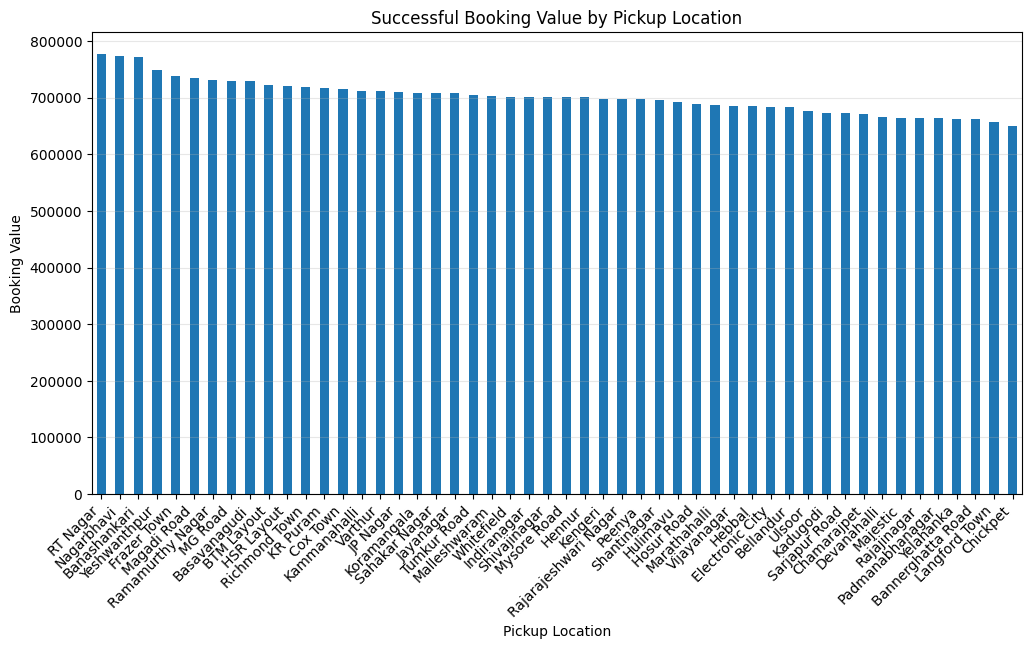

In [21]:
plt.figure(figsize=(12, 6))

revenue_by_city.plot(kind="bar")

plt.title("Successful Booking Value by Pickup Location")
plt.xlabel("Pickup Location")
plt.ylabel("Booking Value")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../outputs/charts/revenue_by_city.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [22]:
trips_by_city = (
    df.groupby("Pickup_Location")
    .size()
    .sort_values(ascending=False)
)

print(trips_by_city)

Pickup_Location
Banashankari            2201
Yeshwanthpur            2139
RT Nagar                2135
Indiranagar             2133
Sahakar Nagar           2126
Basavanagudi            2120
Ramamurthy Nagar        2116
Vijayanagar             2113
Tumkur Road             2105
Cox Town                2100
Magadi Road             2099
BTM Layout              2091
Hennur                  2090
Whitefield              2087
Mysore Road             2085
Kengeri                 2083
Nagarbhavi              2083
Langford Town           2079
Hosur Road              2074
Kammanahalli            2071
Sarjapur Road           2070
Peenya                  2069
Majestic                2067
Koramangala             2062
KR Puram                2058
Malleshwaram            2058
Hebbal                  2058
Frazer Town             2048
MG Road                 2048
Bannerghatta Road       2046
Yelahanka               2044
Electronic City         2044
HSR Layout              2042
Richmond Town           204

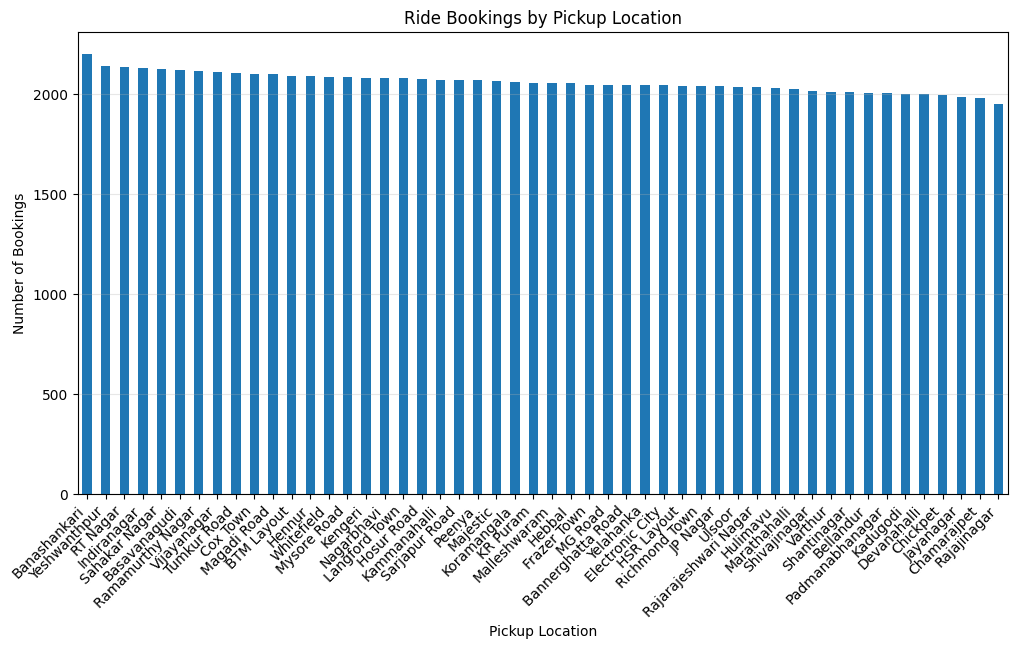

In [23]:
plt.figure(figsize=(12, 6))

trips_by_city.plot(kind="bar")

plt.title("Ride Bookings by Pickup Location")
plt.xlabel("Pickup Location")
plt.ylabel("Number of Bookings")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)

plt.savefig(
    "../outputs/charts/city_wise_usage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight — City-wise Usage

The city-wise analysis compares the number of bookings across pickup locations. 
Locations with higher booking volumes represent areas with greater ride demand 
in this dataset. RapidRide can use this information when planning driver 
availability and vehicle allocation across different locations.

In [24]:
print(successful_rides["Driver_Ratings"].describe())

count    63967.000000
mean         3.997457
std          0.576834
min          3.000000
25%          3.500000
50%          4.000000
75%          4.500000
max          5.000000
Name: Driver_Ratings, dtype: float64


In [25]:
rating_distribution = (
    successful_rides["Driver_Ratings"]
    .value_counts()
    .sort_index()
)

print(rating_distribution)

Driver_Ratings
3.0    1560
3.1    3273
3.2    3161
3.3    3249
3.4    3130
3.5    3235
3.6    3124
3.7    3208
3.8    3313
3.9    3274
4.0    3160
4.1    3231
4.2    3259
4.3    3164
4.4    3185
4.5    3214
4.6    3183
4.7    3232
4.8    3176
4.9    3105
5.0    1531
Name: count, dtype: int64


In [26]:
rating_heatmap = pd.crosstab(
    successful_rides["Driver_Ratings"],
    successful_rides["Vehicle_Type"]
)

print(rating_heatmap)

Vehicle_Type    Auto  Bike  Mini  Prime Plus  Prime SUV  Prime Sedan  eBike
Driver_Ratings                                                             
3.0              209   217   226         216        233          232    227
3.1              456   479   449         463        457          489    480
3.2              450   474   463         440        444          465    425
3.3              473   448   448         471        454          514    441
3.4              462   453   449         460        415          459    432
3.5              430   490   481         428        427          508    471
3.6              477   477   461         453        411          405    440
3.7              491   457   433         455        423          493    456
3.8              465   470   468         507        478          465    460
3.9              412   478   473         460        458          519    474
4.0              447   450   461         455        437          450    460
4.1         

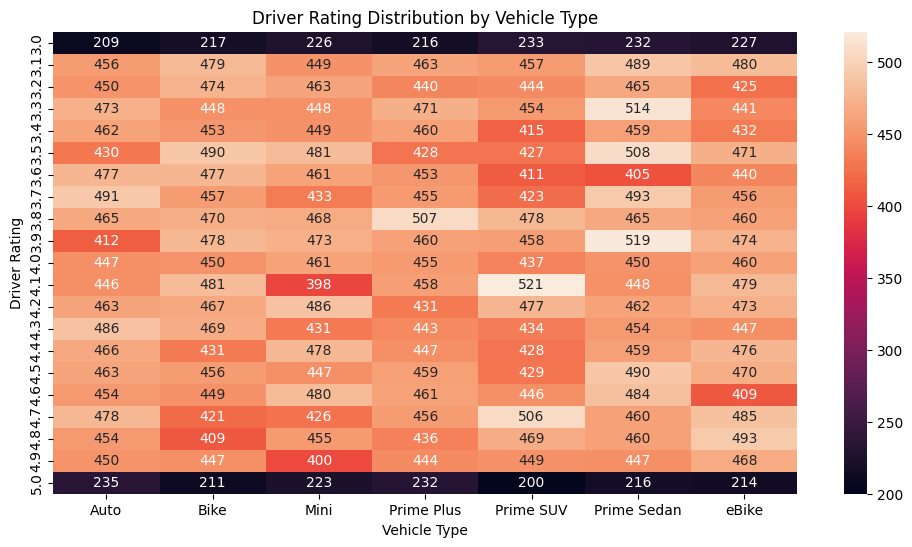

In [27]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    rating_heatmap,
    annot=True,
    fmt="d"
)

plt.title("Driver Rating Distribution by Vehicle Type")
plt.xlabel("Vehicle Type")
plt.ylabel("Driver Rating")

plt.savefig(
    "../outputs/charts/driver_rating_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Business Insight — Driver Ratings

The driver-rating heatmap shows how driver ratings are distributed across 
different vehicle types. It helps identify whether particular vehicle categories 
have a different concentration of lower or higher ratings. RapidRide can use 
this information to monitor service quality and identify areas that may require 
additional driver support or service-quality review.

In [28]:
# Find the busiest booking hour
busiest_hour = trips_by_hour.idxmax()
busiest_hour_count = trips_by_hour.max()

# Find the busiest pickup location
busiest_city = trips_by_city.idxmax()
busiest_city_count = trips_by_city.max()

# Find the city with the highest successful booking value
highest_revenue_city = revenue_by_city.idxmax()
highest_revenue_value = revenue_by_city.max()

# Average driver rating
average_driver_rating = successful_rides["Driver_Ratings"].mean()

print("BUSINESS ANALYSIS RESULTS")
print("-------------------------")
print(f"Busiest booking hour: {busiest_hour}:00")
print(f"Bookings during busiest hour: {busiest_hour_count}")

print(f"\nBusiest pickup location: {busiest_city}")
print(f"Bookings from busiest location: {busiest_city_count}")

print(f"\nHighest successful booking value location: {highest_revenue_city}")
print(f"Successful booking value: {highest_revenue_value:,.0f}")

print(f"\nAverage driver rating: {average_driver_rating:.2f}")

BUSINESS ANALYSIS RESULTS
-------------------------
Busiest booking hour: 12:00
Bookings during busiest hour: 4408

Busiest pickup location: Banashankari
Bookings from busiest location: 2201

Highest successful booking value location: RT Nagar
Successful booking value: 777,106

Average driver rating: 4.00


In [29]:
most_common_rating = rating_distribution.idxmax()
most_common_rating_count = rating_distribution.max()

print("Most common driver rating:", most_common_rating)
print("Number of successful rides with this rating:", most_common_rating_count)

Most common driver rating: 3.8
Number of successful rides with this rating: 3313


## Business Findings

### Finding 1 — Ride demand is relatively consistent throughout the day

The hourly analysis shows that ride bookings remain fairly consistent across the 24 hours, with booking volumes generally staying around the same range. The highest activity occurs around midday, while some early-morning and evening hours have comparatively lower volumes. This suggests that RapidRide should maintain driver availability throughout the day rather than focusing resources on only one peak period.

### Finding 2 — Booking demand fluctuates over time

The time-series analysis shows several increases and decreases in daily booking volume rather than a continuous upward or downward trend. This indicates that demand changes from day to day. RapidRide can monitor these fluctuations when planning driver availability and operational resources.

### Finding 3 — Booking value is distributed across many pickup locations

The successful booking value analysis shows that booking value is spread across many pickup locations. RT Nagar has the highest successful booking value in the displayed results, while locations such as Langar Chowk are toward the lower end. This indicates that revenue opportunities are distributed across multiple locations rather than being concentrated in a single pickup area.

### Finding 4 — Driver ratings are concentrated around the middle-to-high range

The driver-rating heatmap shows that most rating counts are concentrated around the 4.x range across the different vehicle types. This indicates that the majority of recorded driver ratings fall between moderate and high ratings, while very low and perfect ratings occur less frequently.


## Conclusion

The exploratory analysis provided an overall view of RapidRide's ride-booking activity by examining trip volume, hourly demand, booking trends over time, successful booking value, pickup-location usage, and driver ratings.

The results show that booking demand remains relatively consistent across the hours of the day but fluctuates from day to day. Successful booking value and ride volume are distributed across many pickup locations, while driver ratings are mainly concentrated in the middle-to-high rating range.

These findings can help RapidRide's non-technical staff understand demand patterns, compare pickup locations, monitor booking value, and review driver-rating patterns for operational planning.

## Limitations

This analysis is based on the variables and records available in the cleaned ride-booking dataset. The findings describe patterns in the available data and should not be treated as evidence of causal relationships.

The analysis does not include additional factors such as weather, traffic conditions, customer demographics, special events, or promotional campaigns. Including these variables in future analysis could provide additional explanations for changes in ride demand and customer ratings.

## Dataset Overview

The cleaned dataset contains **103,024 booking records** and **18 columns**.

The analysis covers booking status, booking value, pickup location, vehicle type, ride distance, and driver ratings. The dataset contains both successful and unsuccessful booking records, so successful rides are used separately where the analysis specifically concerns completed rides.